In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Set plot style for better visuals
sns.set(style="whitegrid")

print("Libraries imported successfully!")

# Load the dataset
try:
    # IMPORTANT: Ensure your CSV file is named 'Accidents.csv' or change the filename below
    df = pd.read_csv('Accidents.csv', low_memory=False)
    print("Dataset loaded successfully.")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print("Error: Accidents.csv not found. Please download the dataset and place it in the correct directory.")

# Display the first few rows to confirm it's loaded
df.head()

Libraries imported successfully!
Dataset loaded successfully.
Dataset shape: (50000, 34)


,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,201243N256052,C,87.0,NaN,NaN,Slight,NaN,2012-05-25,Friday,1.0,...,Thames Valley,Dry,Single carriageway,NaN,40.0,08:27,Rural,Fine no high winds,2012,No
1,200750B71P198,B,3254.0,NaN,0.0,Serious,NaN,2007-12-11,Tuesday,1.0,...,Devon and Cornwall,Wet or damp,Dual carriageway,NaN,60.0,16:15,Rural,Fine no high winds,2007,No
2,200601MM70553,A,2214.0,C,0.0,Slight,NaN,2006-07-03,Monday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,17:07,Urban,Fine no high winds,2006,No
3,200597UD20709,A,77.0,Unclassified,0.0,Slight,NaN,2005-09-17,Saturday,1.0,...,Strathclyde,Wet or damp,Single carriageway,NaN,60.0,16:10,Rural,Raining no high winds,2005,Yes
4,2016300019227,B,6013.0,Unclassified,0.0,Slight,NaN,2016-05-12,Thursday,1.0,...,Derbyshire,Dry,Single carriageway,NaN,30.0,14:50,Urban,Fine no high winds,2016,No


Missing values before cleaning:
Severity            0
Road_Conditions     0
Weather             0
Road_Type           0
Light_Conditions    0
Speed_Limit         1
Junction_Control    0
dtype: int64

Missing values after cleaning:
Severity            0
Road_Conditions     0
Weather             0
Road_Type           0
Light_Conditions    0
Speed_Limit         0
Junction_Control    0
dtype: int64

Shape of cleaned data: (49999, 7)


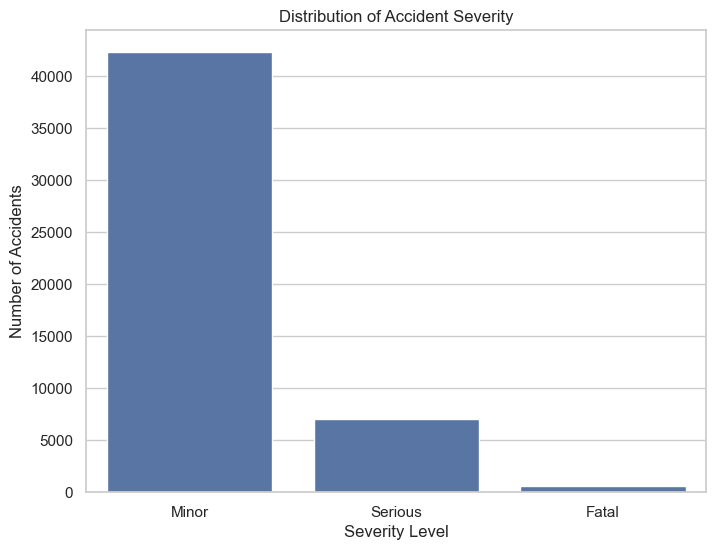


Severity Value Counts (Corrected):
Severity
Minor      42330
Serious     7063
Fatal        606
Name: count, dtype: int64


In [7]:
# --- FINAL RECOMMENDED CODE ---
# Add more features to give the model enough information to make real predictions.

# Step 1: Select a richer set of features
features_to_use = {
    'Accident_Severity': 'Severity',
    'Road_Surface_Conditions': 'Road_Conditions',
    'Weather_Conditions': 'Weather',
    'Road_Type': 'Road_Type',
    'Light_Conditions': 'Light_Conditions', # Added feature
    'Speed_limit': 'Speed_Limit',         # Added feature
    'Junction_Control': 'Junction_Control'  # Added feature
}

df_clean = df[features_to_use.keys()].rename(columns=features_to_use)

# Step 2: Handle missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum())
df_clean.dropna(inplace=True)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

# Step 3: Correct the severity labels
df_clean['Severity'] = df_clean['Severity'].replace({'Slight': 'Minor'})
target_classes = ['Minor', 'Serious', 'Fatal']
df_clean = df_clean[df_clean['Severity'].isin(target_classes)]

print(f"\nShape of cleaned data: {df_clean.shape}")

# Step 4: Visualize the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Severity', data=df_clean, order=target_classes)
plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')
plt.show()

print("\nSeverity Value Counts (Corrected):")
print(df_clean['Severity'].value_counts())

In [8]:
# Prepare data for modeling
# Separate features (X) and target (y)
X = df_clean.drop('Severity', axis=1)
y = df_clean['Severity']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features have been one-hot encoded.")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y_encoded.shape}")
print(f"Target classes: {le.classes_}")

Features have been one-hot encoded.
Shape of features (X): (49999, 30)
Shape of target (y): (49999,)
Target classes: ['Fatal' 'Minor' 'Serious']


In [9]:
# --- UPDATED MODEL TRAINING CELL ---

# Import the necessary models and SMOTE
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE # <-- Import SMOTE

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# --- Apply SMOTE to the training data ONLY ---
print("Applying SMOTE to balance the training data...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("SMOTE complete. The new training set is balanced.")

# --- Initialize all three models ---
# NOTE: We can remove class_weight='balanced' now that we have used SMOTE
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1)
}

# --- Train each model on the NEW resampled data ---
trained_models = {}
for name, model in models.items():
    print(f"--- Training {name} ---")
    # Train on X_train_resampled and y_train_resampled
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    print(f"{name} training complete.\n")

print("All models have been trained successfully on the balanced data!")

Applying SMOTE to balance the training data...
SMOTE complete. The new training set is balanced.
--- Training Logistic Regression ---


c:\Users\Lenovo\Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression training complete.

--- Training Random Forest ---
Random Forest training complete.

--- Training LightGBM ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 87
[LightGBM] [Info] Number of data points in the train set: 101592, number of used features: 29
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM training complete.

All models have been trained successfully on the balanced data!


--- Evaluation for: Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

       Fatal       0.03      0.45      0.05       121
       Minor       0.87      0.60      0.71      8466
     Serious       0.15      0.23      0.18      1413

    accuracy                           0.55     10000
   macro avg       0.35      0.43      0.32     10000
weighted avg       0.76      0.55      0.63     10000



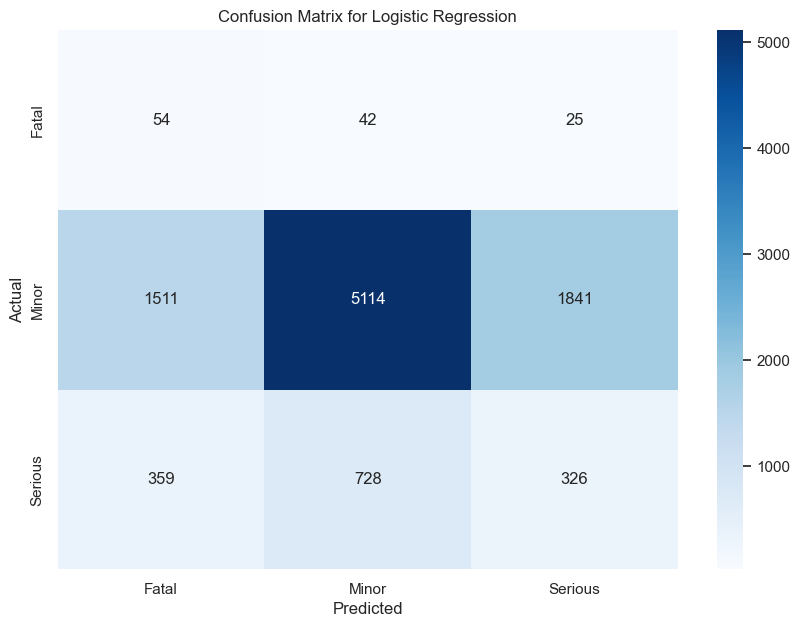

--------------------------------------------------

--- Evaluation for: Random Forest ---
Classification Report:
              precision    recall  f1-score   support

       Fatal       0.03      0.44      0.05       121
       Minor       0.87      0.56      0.68      8466
     Serious       0.14      0.25      0.18      1413

    accuracy                           0.52     10000
   macro avg       0.35      0.42      0.30     10000
weighted avg       0.76      0.52      0.60     10000



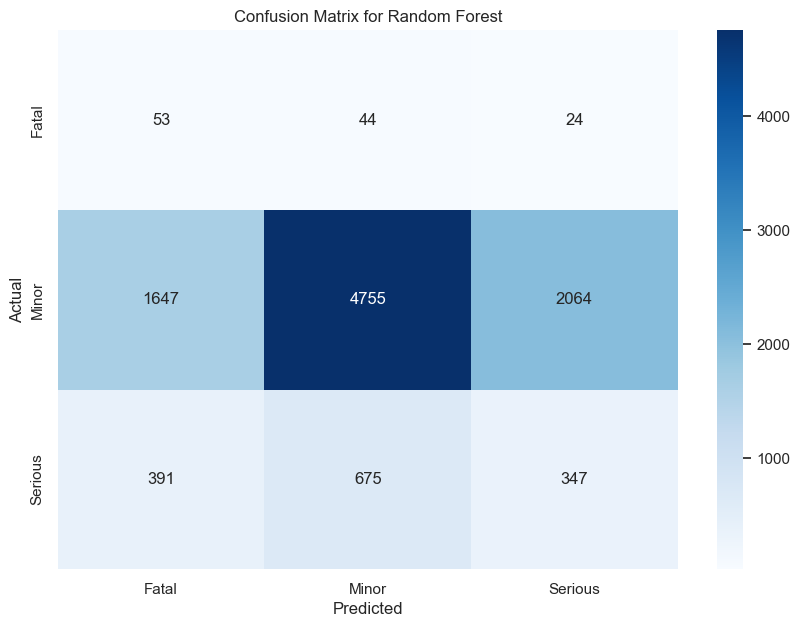

--------------------------------------------------

--- Evaluation for: LightGBM ---
Classification Report:
              precision    recall  f1-score   support

       Fatal       0.03      0.45      0.05       121
       Minor       0.87      0.60      0.71      8466
     Serious       0.15      0.22      0.17      1413

    accuracy                           0.54     10000
   macro avg       0.35      0.42      0.31     10000
weighted avg       0.76      0.54      0.62     10000



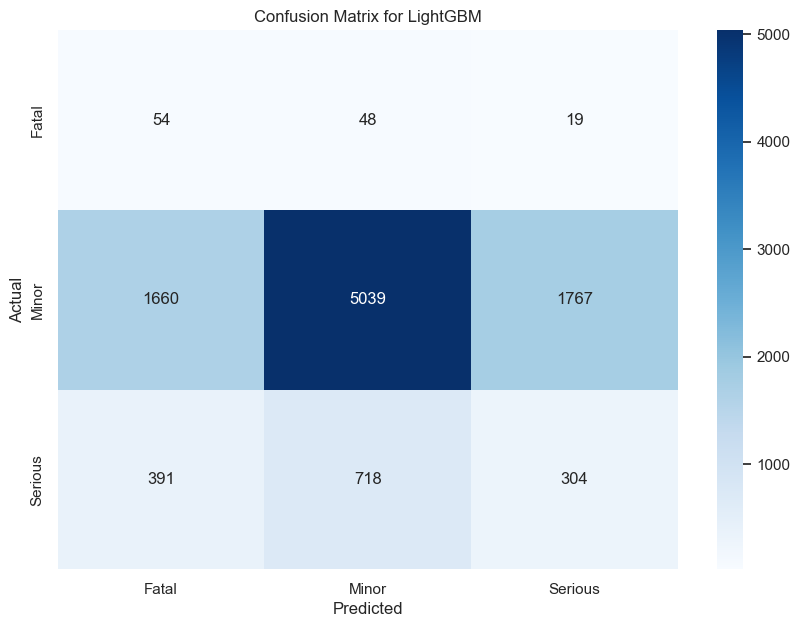

--------------------------------------------------



In [10]:
# --- Evaluate each trained model ---

for name, model in trained_models.items():
    print(f"--- Evaluation for: {name} ---")
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Print the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # Display the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print("-" * 50 + "\n")